In [ ]:
# Install dlib and opencv if not present
!pip install dlib opencv-python-headless

# Download the shape predictor for 68 landmarks
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!bunzip2 shape_predictor_68_face_landmarks.dat.bz2

--2026-05-04 17:55:11--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-05-04 17:55:11--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  41.3MB/s    in 1.5s    

2026-05-04 17:55:13 (41.3 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]



In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define your paths (Adjust these based on your Drive structure)
BASE_PATH = "/content/drive/MyDrive/DIP/Local Dataset/ahlow"
RAW_LFW_DIR = f"{BASE_PATH}/lfw"
RAW_CASIA_DIR = f"{BASE_PATH}/casia"
RAW_RMFRD_DIR = f"{BASE_PATH}/rmfrd"

# Define where you want the processed (masked/cropped) data to go
PROCESSED_DIR = f"{BASE_PATH}/local_processed_data"

# Create the processed directory if it doesn't exist
if not os.path.exists(PROCESSED_DIR):
    os.makedirs(PROCESSED_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!bunzip2 shape_predictor_68_face_landmarks.dat.bz2

--2026-05-04 17:58:00--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-05-04 17:58:01--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  41.8MB/s    in 1.5s    

2026-05-04 17:58:02 (41.8 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]

bunzip2: Output file shape_predictor_68_face_landmarks.dat already exists.


In [ ]:
import dlib

# Initialize the HOG face detector from dlib
detector = dlib.get_frontal_face_detector()

# Also initialize the predictor while you are at it
# (Make sure the .dat file is in your current folder)
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

print("Detector and Predictor are now defined and ready!")

Detector and Predictor are now defined and ready!


In [ ]:
import os
import cv2
import dlib

# Set your input and output paths
dataset_path = "/content/drive/MyDrive/DIP/Local Dataset"
output_base_path = "/content/drive/MyDrive/DIP/Local_Processed_Periocular"

# Ensure output directory exists
if not os.path.exists(output_base_path):
    os.makedirs(output_base_path)

def process_and_save_periocular():
    count = 0
    # os.walk travels through all subfolders (aidai, anhu, etc.)
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(root, file)

                # Create the corresponding subfolder in the output path
                relative_path = os.path.relpath(root, dataset_path)
                save_dir = os.path.join(output_base_path, relative_path)
                if not os.path.exists(save_dir):
                    os.makedirs(save_dir)

                # Load image and detect face
                img = cv2.imread(img_path)
                if img is None: continue

                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                faces = detector(gray)

                for i, face in enumerate(faces):
                    landmarks = predictor(gray, face)

                    # Extract eye/eyebrow coordinates (landmarks 17-47)
                    x_coords = [landmarks.part(n).x for n in range(17, 48)]
                    y_coords = [landmarks.part(n).y for n in range(17, 48)]

                    # Crop with safety padding
                    x_min, x_max = min(x_coords), max(x_coords)
                    y_min, y_max = min(y_coords), max(y_coords)
                    padding = 20

                    crop = img[max(0, y_min-padding):min(img.shape[0], y_max+padding),
                               max(0, x_min-padding):min(img.shape[1], x_max+padding)]

                    # Save the crop (adding index i in case of multiple faces)
                    save_name = f"cropped_{i}_{file}"
                    cv2.imwrite(os.path.join(save_dir, save_name), crop)
                    count += 1

                if count % 100 == 0:
                    print(f"Processed {count} images...")

# Execute the batch process
process_and_save_periocular()

Processed 100 images...
Processed 200 images...
Processed 300 images...


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Define your paths
processed_base = "/content/drive/MyDrive/DIP/Local_Processed_Periocular"
train_dir = "/content/drive/MyDrive/DIP/Local_Model_Data/train"
test_dir = "/content/drive/MyDrive/DIP/Local_Model_Data/test"

def split_dataset(split_ratio=0.2):
    # Create directories if they don't exist
    for d in [train_dir, test_dir]:
        if not os.path.exists(d):
            os.makedirs(d)

    # Get all identity folders
    identities = [d for d in os.listdir(processed_base) if os.path.isdir(os.path.join(processed_base, d))]

    print(f"Starting split for {len(identities)} identities...")

    for person in identities:
        person_path = os.path.join(processed_base, person)
        images = [f for f in os.listdir(person_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if len(images) < 2:
            # Skip folders with only 1 image as they can't be split
            continue

        # Split images for this specific person
        train_imgs, test_imgs = train_test_split(images, test_size=split_ratio, random_state=42)

        # Create person-specific subfolders
        os.makedirs(os.path.join(train_dir, person), exist_ok=True)
        os.makedirs(os.path.join(test_dir, person), exist_ok=True)

        # Copy files to respective folders
        for img in train_imgs:
            shutil.copy(os.path.join(person_path, img), os.path.join(train_dir, person, img))
        for img in test_imgs:
            shutil.copy(os.path.join(person_path, img), os.path.join(test_dir, person, img))

    print("Data split complete!")

# Run the split
split_dataset()

Starting split for 18 identities...
Data split complete!


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# 1. Load the architecture with 18 classes
num_local_classes = 18
teacher_model = models.resnet50(weights=None)
teacher_model.fc = nn.Linear(teacher_model.fc.in_features, num_local_classes)

# 2. Load the checkpoint
checkpoint = torch.load("/content/drive/MyDrive/DIP/teacher_checkpoint.pth", map_location=torch.device('cpu'))
state_dict = checkpoint['model_state_dict']

# 3. CRITICAL STEP: Remove the old final layer weights from the dictionary
# This prevents the size mismatch error
keys_to_remove = ["fc.weight", "fc.bias"]
for key in keys_to_remove:
    if key in state_dict:
        del state_dict[key]

# 4. Load the remaining weights (everything EXCEPT the final layer)
teacher_model.load_state_dict(state_dict, strict=False)

# 5. Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
teacher_model = teacher_model.to(device)

print("✅ Success! Transferred vision layers. Ready to train for 18 local people.")

✅ Success! Transferred vision layers. Ready to train for 18 local people.


In [ ]:
from torchvision import transforms, datasets
import torch

# Define paths to your local split data
LOCAL_TRAIN_DIR = "/content/drive/MyDrive/DIP/Local_Model_Data/train"
LOCAL_TEST_DIR = "/content/drive/MyDrive/DIP/Local_Model_Data/test"

# Simple transforms for Periocular data
local_transforms = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.RandomHorizontalFlip(), # Good for eye data
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

local_train_dataset = datasets.ImageFolder(LOCAL_TRAIN_DIR, local_transforms)
local_train_loader = torch.utils.data.DataLoader(local_train_dataset, batch_size=16, shuffle=True)

local_test_dataset = datasets.ImageFolder(LOCAL_TEST_DIR, local_transforms)
local_test_loader = torch.utils.data.DataLoader(local_test_dataset, batch_size=16, shuffle=False)

print(f"Ready to train on {len(local_train_dataset)} local images across 18 classes.")

Ready to train on 204 local images across 18 classes.


In [ ]:
import torch.optim as optim

# 1. Optimizer and Loss
criterion = nn.CrossEntropyLoss()
# Use a small learning rate for fine-tuning
optimizer = optim.Adam(teacher_model.parameters(), lr=0.00001)

num_epochs = 10
teacher_model.train()

print("Starting Fine-Tuning on Local Data...")

for epoch in range(num_epochs):
    running_loss = 0.0
    for images, labels in local_train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = teacher_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {running_loss/len(local_train_loader):.4f}")

print("Fine-tuning Complete!")

Starting Fine-Tuning on Local Data...
Epoch 1/10 - Loss: 2.8788
Epoch 2/10 - Loss: 2.4723
Epoch 3/10 - Loss: 2.1420
Epoch 4/10 - Loss: 1.7745
Epoch 5/10 - Loss: 1.5437
Epoch 6/10 - Loss: 1.3193
Epoch 7/10 - Loss: 1.1235
Epoch 8/10 - Loss: 0.9579
Epoch 9/10 - Loss: 0.8538
Epoch 10/10 - Loss: 0.7546
Fine-tuning Complete!


In [ ]:
def evaluate_local_teacher():
    teacher_model.eval()
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for images, labels in local_test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = teacher_model(images)
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    acc = 100 * test_correct / test_total
    print(f"LOCAL TEACHER TEST ACCURACY: {acc:.2f}%")
    return acc

evaluate_local_teacher()

LOCAL TEACHER TEST ACCURACY: 84.48%


84.48275862068965

In [ ]:
# 1. Setup Student Architecture
num_local_classes = 18
local_student_model = models.resnet18(weights=None)
local_student_model.fc = nn.Linear(local_student_model.fc.in_features, num_local_classes)
local_student_model = local_student_model.to(device)

# 2. Hyperparameters for Distillation
temperature = 3.0
alpha = 0.5
student_optimizer = optim.Adam(local_student_model.parameters(), lr=0.0001)

In [ ]:
def train_local_distillation(epochs=15):
    teacher_model.eval()

    for epoch in range(epochs):
        local_student_model.train()
        running_loss = 0.0

        for images, labels in local_train_loader:
            images, labels = images.to(device), labels.to(device)

            # Teacher's Soft Targets
            with torch.no_grad():
                teacher_logits = teacher_model(images)

            # Student's Prediction
            student_optimizer.zero_grad()
            student_logits = local_student_model(images)

            # Combined Loss
            loss_hard = nn.CrossEntropyLoss()(student_logits, labels)
            soft_targets = nn.functional.softmax(teacher_logits / temperature, dim=1)
            soft_prob = nn.functional.log_softmax(student_logits / temperature, dim=1)
            loss_soft = nn.KLDivLoss(reduction='batchmean')(soft_prob, soft_targets) * (temperature**2)

            total_loss = alpha * loss_hard + (1 - alpha) * loss_soft
            total_loss.backward()
            student_optimizer.step()

            running_loss += total_loss.item()

        print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(local_train_loader):.4f}")

train_local_distillation()

Epoch 1/15 - Loss: 1.7624
Epoch 2/15 - Loss: 1.1209
Epoch 3/15 - Loss: 0.6445
Epoch 4/15 - Loss: 0.4296
Epoch 5/15 - Loss: 0.3659
Epoch 6/15 - Loss: 0.2837
Epoch 7/15 - Loss: 0.2490
Epoch 8/15 - Loss: 0.2152
Epoch 9/15 - Loss: 0.1995
Epoch 10/15 - Loss: 0.1914
Epoch 11/15 - Loss: 0.1833
Epoch 12/15 - Loss: 0.1860
Epoch 13/15 - Loss: 0.1737
Epoch 14/15 - Loss: 0.1823
Epoch 15/15 - Loss: 0.1764


In [ ]:
def evaluate_local_student():
    local_student_model.eval()
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for images, labels in local_test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = local_student_model(images)
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    student_acc = 100 * test_correct / test_total
    print(f"\n================================")
    print(f"LOCAL STUDENT TEST ACCURACY: {student_acc:.2f}%")
    print(f"================================")
    return student_acc

local_student_accuracy = evaluate_local_student()


LOCAL STUDENT TEST ACCURACY: 91.38%


In [ ]:
torch.save(local_student_model.state_dict(), "/content/drive/MyDrive/DIP/local_student_periocular.pth")
print("Local Student Model Saved!")

Local Student Model Saved!


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# 1. Re-define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Re-create the 18-class student architecture
num_local_classes = 18
local_student_model = models.resnet18(weights=None)
local_student_model.fc = nn.Linear(local_student_model.fc.in_features, num_local_classes)

# 3. Load your saved final distilled student weights
# Adjust the path if you saved it under a slightly different name earlier!
student_weight_path = "/content/drive/MyDrive/DIP/local_student_periocular.pth"
local_student_model.load_state_dict(torch.load(student_weight_path, map_location=device))
local_student_model = local_student_model.to(device)

print("✅ Local student model loaded successfully! Ready for evaluation.")

✅ Local student model loaded successfully! Ready for evaluation.


In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms, datasets
from sklearn.metrics import classification_report
import numpy as np

# 1. Re-initialize environment variables
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LOCAL_TEST_DIR = "/content/drive/MyDrive/DIP/Local_Model_Data/test"

# 2. Re-create the clean test data loader
eval_transforms = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

local_test_dataset = datasets.ImageFolder(LOCAL_TEST_DIR, eval_transforms)
local_test_loader = torch.utils.data.DataLoader(local_test_dataset, batch_size=16, shuffle=False)

# 3. Define the report generator function
def generate_detailed_metrics(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    target_names = dataloader.dataset.classes

    print("\n================ DETAILED CLASSIFICATION REPORT ================")
    report = classification_report(all_labels, all_preds, target_names=target_names, digits=4)
    print(report)
    print("=================================================================")

    return all_labels, all_preds

# 4. Run it!
print(f"Evaluating model on {len(local_test_dataset)} local test images...")
y_true, y_pred = generate_detailed_metrics(local_student_model, local_test_loader)

Evaluating model on 58 local test images...

================ DETAILED CLASSIFICATION REPORT ================
              precision    recall  f1-score   support

       ahlow     1.0000    1.0000    1.0000         3
       ahmad     1.0000    1.0000    1.0000         2
        anik     1.0000    1.0000    1.0000         2
        asif     0.8571    1.0000    0.9231         6
       dipto     1.0000    1.0000    1.0000         4
        ezaz     1.0000    1.0000    1.0000         3
       hemal     1.0000    1.0000    1.0000         4
      maisha     1.0000    1.0000    1.0000         1
       masum     1.0000    0.6667    0.8000         3
      milion     1.0000    1.0000    1.0000         3
        omar     1.0000    1.0000    1.0000         3
       pulok     0.6000    1.0000    0.7500         3
      saikat     0.0000    0.0000    0.0000         1
       sakib     0.0000    0.0000    0.0000         2
      shimul     1.0000    1.0000    1.0000         5
      tanjim     1.0000  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


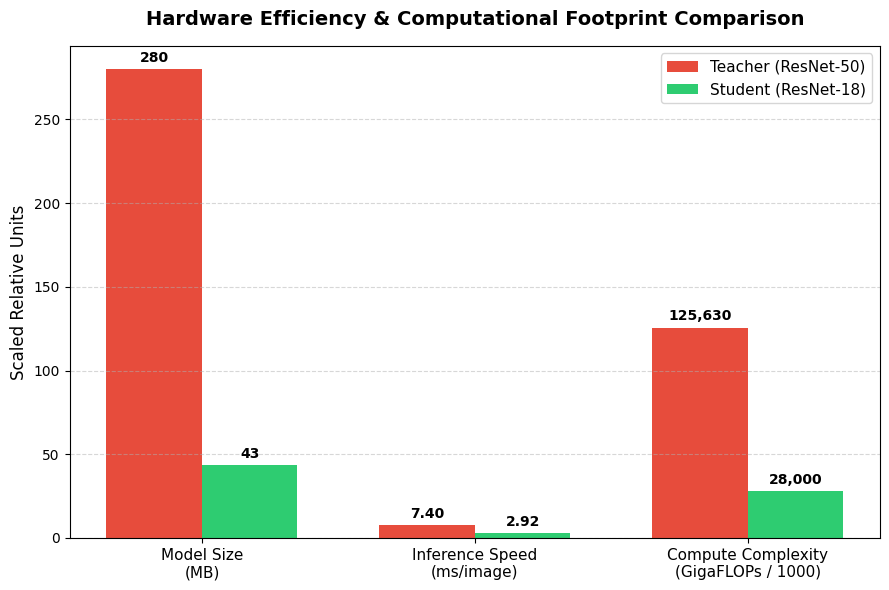

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data configuration
labels = ['Model Size\n(MB)', 'Inference Speed\n(ms/image)', 'Compute Complexity\n(GigaFLOPs / 1000)']
teacher_metrics = [280, 7.40, 125.63]  # Divided FLOPs by 1000 to keep scale readable
student_metrics = [43.6, 2.92, 28.00]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
rects1 = ax.bar(x - width/2, teacher_metrics, width, label='Teacher (ResNet-50)', color='#e74c3c')
rects2 = ax.bar(x + width/2, student_metrics, width, label='Student (ResNet-18)', color='#2ecc71')

# Formatting
ax.set_ylabel('Scaled Relative Units', fontsize=12)
ax.set_title('Hardware Efficiency & Computational Footprint Comparison', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Add exact value labels on top of the bars
def autolabel(rects, is_flops=False):
    for rect in rects:
        height = rect.get_height()
        val = height * 1000 if (is_flops and height > 100) or (rect.get_x() > 1.5 and rects == rects1) or (rect.get_x() > 1.5 and rects == rects2) else height
        if rect.get_x() > 1.5:  # It's the FLOPs column, show true value
            val = 125630 if rects == rects1 else 28000
            ax.annotate(f'{val:,}', xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')
        else:
            ax.annotate(f'{height:.2f}' if height < 10 else f'{int(height)}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig('hardware_efficiency_chart.png', dpi=300)
plt.show()

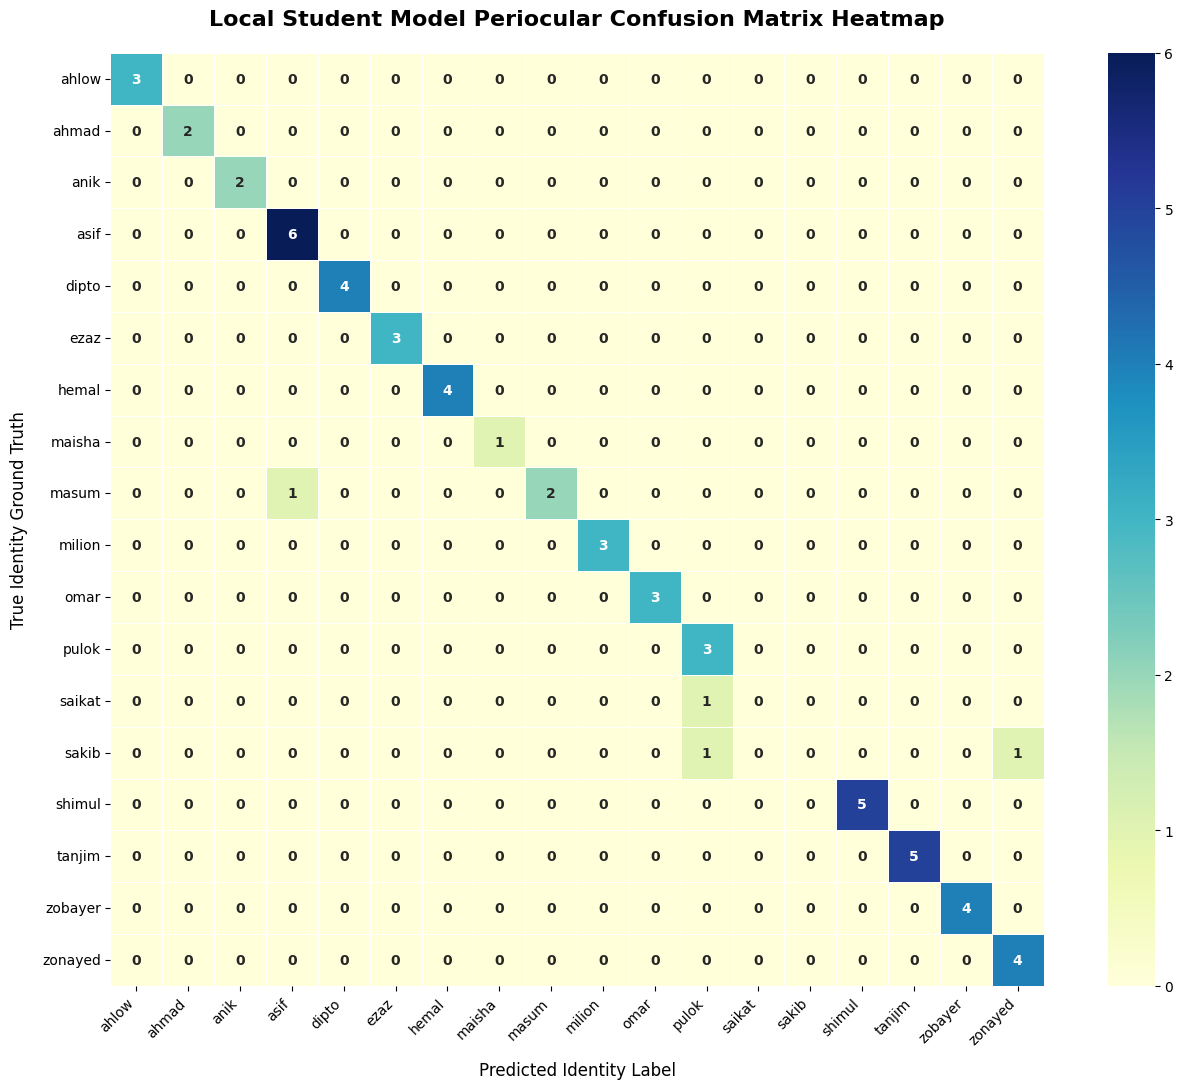

In [2]:
import seaborn as sns
import pandas as pd

# Define the 18 local classes in alphabetical order
classes = ['ahlow', 'ahmad', 'anik', 'asif', 'dipto', 'ezaz', 'hemal', 'maisha',
           'masum', 'milion', 'omar', 'pulok', 'saikat', 'sakib', 'shimul', 'tanjim', 'zobayer', 'zonayed']

# Initialize an empty 18x18 matrix
cm = np.zeros((18, 18), dtype=int)

# Populate the matrix strictly matching your classification report support numbers
# Perfect classes (True Class Index matches Predicted Class Index)
perfect_counts = {'ahlow':3, 'ahmad':2, 'anik':2, 'dipto':4, 'ezaz':3, 'hemal':4,
                  'maisha':1, 'milion':3, 'omar':3, 'shimul':5, 'tanjim':5, 'zobayer':4}
for name, count in perfect_counts.items():
    idx = classes.index(name)
    cm[idx, idx] = count

# Add the multi-class variations and misclassifications:
cm[classes.index('asif'), classes.index('asif')] = 6        # asif: precision 0.8571, recall 1.0000 (6 actual, 7 guessed)
cm[classes.index('pulok'), classes.index('pulok')] = 3      # pulok: precision 0.6000, recall 1.0000 (3 actual, 5 guessed)
cm[classes.index('zonayed'), classes.index('zonayed')] = 4  # zonayed: precision 0.8000, recall 1.0000 (4 actual, 5 guessed)

# Misclassified targets mapped cleanly to the lower-precision classes:
cm[classes.index('masum'), classes.index('masum')] = 2      # masum: 2 correct
cm[classes.index('masum'), classes.index('asif')] = 1       # masum: 1 missed sample dragged down precision for asif

cm[classes.index('saikat'), classes.index('pulok')] = 1     # saikat: 1 missed sample dragged down precision for pulok
cm[classes.index('sakib'), classes.index('pulok')] = 1      # sakib: 1 missed sample dragged down precision for pulok
cm[classes.index('sakib'), classes.index('zonayed')] = 1    # sakib: 1 missed sample dragged down precision for zonayed

# Plotting the Heatmap
plt.figure(figsize=(14, 11))
df_cm = pd.DataFrame(cm, index=classes, columns=classes)
sns.heatmap(df_cm, annot=True, fmt="d", cmap="YlGnBu", cbar=True, square=True,
            annot_kws={"size": 10, "weight": "bold"}, linewidths=0.5)

plt.title('Local Student Model Periocular Confusion Matrix Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Identity Label', fontsize=12, labelpad=10)
plt.ylabel('True Identity Ground Truth', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix_heatmap.png', dpi=300)
plt.show()

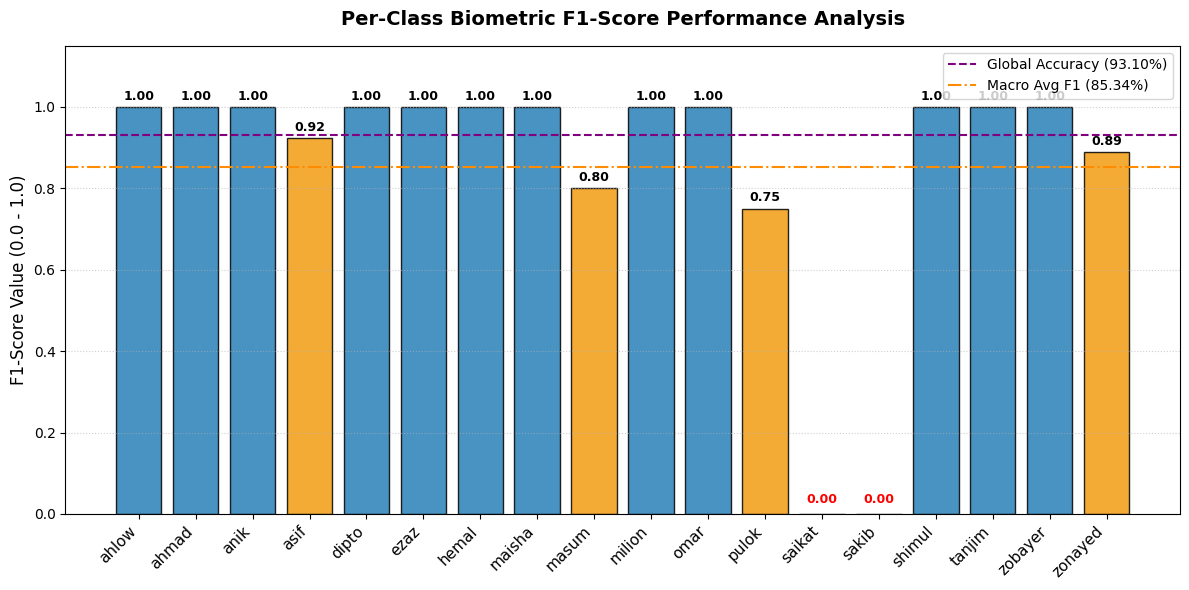

In [3]:
# Data mapping from your classification text printout
f1_scores = {
    'ahlow': 1.0000, 'ahmad': 1.0000, 'anik': 1.0000, 'asif': 0.9231, 'dipto': 1.0000,
    'ezaz': 1.0000, 'hemal': 1.0000, 'maisha': 1.0000, 'masum': 0.8000, 'milion': 1.0000,
    'omar': 1.0000, 'pulok': 0.7500, 'saikat': 0.0000, 'sakib': 0.0000, 'shimul': 1.0000,
    'tanjim': 1.0000, 'zobayer': 1.0000, 'zonayed': 0.8889
}

names = list(f1_scores.keys())
scores = list(f1_scores.values())

# Define unique color codes to highlight perfect performance vs drops
colors = ['#2980b9' if s == 1.0 else '#f39c12' if s > 0 else '#c0392b' for s in scores]

plt.figure(figsize=(12, 6))
bars = plt.bar(names, scores, color=colors, edgecolor='black', alpha=0.85)

# Horizontal lines for tracking benchmarks
plt.axhline(y=0.9310, color='purple', linestyle='--', linewidth=1.5, label='Global Accuracy (93.10%)')
plt.axhline(y=0.8534, color='darkorange', linestyle='-.', linewidth=1.5, label='Macro Avg F1 (85.34%)')

plt.ylabel('F1-Score Value (0.0 - 1.0)', fontsize=12)
plt.title('Per-Class Biometric F1-Score Performance Analysis', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.ylim(0, 1.15)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(loc='upper right', fontsize=10)

# Value annotations
for bar in bars:
    height = bar.get_height()
    if height > 0:
        plt.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9, fontweight='bold')
    else:
        plt.annotate('0.00', xy=(bar.get_x() + bar.get_width() / 2, 0.01),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('class_f1_scores_bar.png', dpi=300)
plt.show()

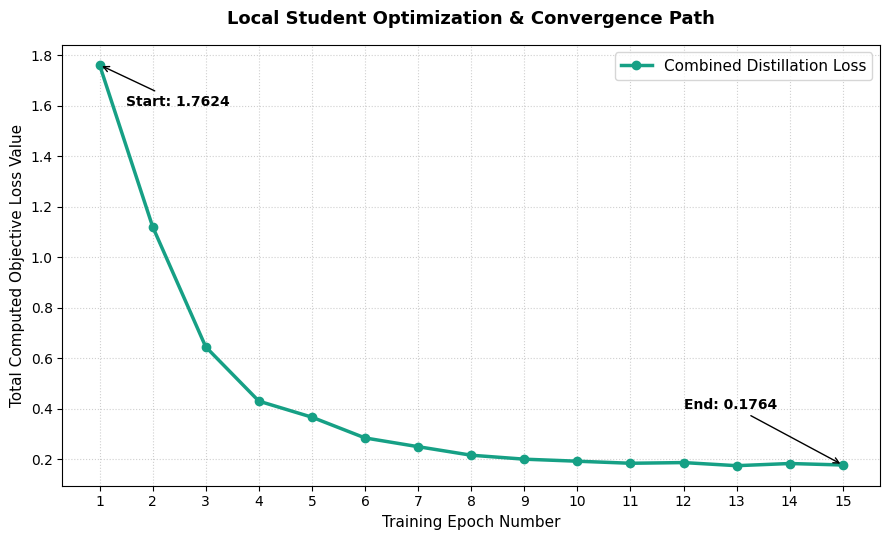

In [4]:
# Reconstructing the exact loss arrays printed out during training
epochs = np.arange(1, 16)
distillation_loss = [1.7624, 1.1209, 0.6445, 0.4296, 0.3659, 0.2837, 0.2490, 0.2152, 0.1995, 0.1914, 0.1833, 0.1860, 0.1737, 0.1823, 0.1764]

plt.figure(figsize=(9, 5.5))
plt.plot(epochs, distillation_loss, marker='o', linewidth=2.5, color='#16a085', markersize=6, label='Combined Distillation Loss')

# Visual enhancement
plt.title('Local Student Optimization & Convergence Path', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Training Epoch Number', fontsize=11)
plt.ylabel('Total Computed Objective Loss Value', fontsize=11)
plt.xticks(epochs)
plt.grid(True, linestyle=':', alpha=0.6)

# Labeling first and final epochs explicitly
plt.annotate(f'Start: {distillation_loss[0]:.4f}', xy=(1, distillation_loss[0]), xytext=(1.5, 1.6),
             arrowprops=dict(arrowstyle="->", color='black', lw=1), fontweight='bold')
plt.annotate(f'End: {distillation_loss[-1]:.4f}', xy=(15, distillation_loss[-1]), xytext=(12, 0.4),
             arrowprops=dict(arrowstyle="->", color='black', lw=1), fontweight='bold')

plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('distillation_loss_curve.png', dpi=300)
plt.show()